# 04 - Exploratory Analysis

**Question:** What has Bandcamp Daily actually covered in fifteen years, and
how has that changed?

This notebook profiles the archive before any hypothesis gets tested — shape,
coverage, quality, and the handful of distributions that shape every later
question.

In [1]:
import sys
from pathlib import Path

# Make the pipeline package importable without installing it, so the notebook
# runs on a fresh clone. `pip install -e .` also works and is preferred.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bandcamp_aotd.logging_config import setup_logging

setup_logging()

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

from bandcamp_aotd import config

sns.set_theme(style="whitegrid")
PALETTE = ["#629aa9", "#e07a5f", "#3d5a80", "#81b29a", "#f2cc8f"]
ACCENT = PALETTE[0]

df = pd.read_csv(config.ANALYTICS_CSV, parse_dates=["published_date"])
print(f"{len(df):,} articles | {df['published_date'].min():%b %Y} - {df['published_date'].max():%b %Y}")
df.head(3)

2,368 articles | Oct 2011 - Sep 2026


,article_id,article_url,article_slug,published_date,year,quarter,month,month_name,iso_week,day_of_month,...,spotify_release_date_precision,spotify_album_type,spotify_total_tracks,spotify_image_url,spotify_upc,spotify_ean,spotify_copyright,spotify_artist_status,spotify_artist_image_url,spotify_artist_url
0,f8bb3e7108af5b49,NaN,NaN,2011-10-28,2011,4,10,October,43,28,...,day,album,9.0,https://i.scdn.co/image/ab67616d0000b273257def...,NaN,NaN,NaN,matched,https://i.scdn.co/image/8a012df7c68f41f801f1f9...,https://open.spotify.com/artist/0UQCSEnTVyI8gt...
1,6994f0121e72977f,NaN,NaN,2011-11-06,2011,4,11,November,44,6,...,day,album,11.0,https://i.scdn.co/image/ab67616d0000b273106f3f...,NaN,NaN,NaN,matched,https://i.scdn.co/image/b21c26b4f4c381b762492a...,https://open.spotify.com/artist/3qPpwz6S0CbgMz...
2,01bfd63e9dbec0f0,NaN,NaN,2011-11-14,2011,4,11,November,46,14,...,day,single,1.0,https://i.scdn.co/image/ab67616d0000b27371a985...,NaN,NaN,NaN,matched,https://i.scdn.co/image/ab6761610000e5eb2badbd...,https://open.spotify.com/artist/77FIfTpCa6CKR5...


## Data quality first

Before any chart: how complete is each column, and which gaps are real
missingness versus a pipeline problem?

In [3]:
quality = pd.DataFrame({
    "non_null": df.notna().sum(),
    "null_pct": (df.isna().mean() * 100).round(1),
    "distinct": df.nunique(),
})
quality.sort_values("null_pct", ascending=False).head(15)

,non_null,null_pct,distinct
spotify_copyright,0,100.0,0
spotify_ean,0,100.0,0
spotify_upc,0,100.0,0
article_slug,118,95.0,118
article_url,118,95.0,118
state,1379,41.8,54
spotify_artist_url,1881,20.6,1644
spotify_match_album,1881,20.6,1877
spotify_id,1881,20.6,1881
spotify_url,1881,20.6,1881


Three gaps are worth naming explicitly, because a reader will ask:

- **`article_url` is empty for historic rows.** The archive was originally
  exported before URLs were captured. That's exactly why the warehouse keys on
  a content hash rather than the URL — see
  `src/bandcamp_aotd/transform/identity.py`.
- **About a fifth of features have no Spotify match.** Partly genuine (many
  Bandcamp picks aren't on Spotify at all — which is rather the point of
  Bandcamp), partly title mismatches. Treat the match rate as a lower bound on
  availability.
- **~3.5% of rows have no location.** The label never filled in the field.
  Nothing to recover; just report it.

## Publication cadence

"Album of the Day" implies one per day. It isn't, quite — and the shape of the
gap says something about how the section has been run.

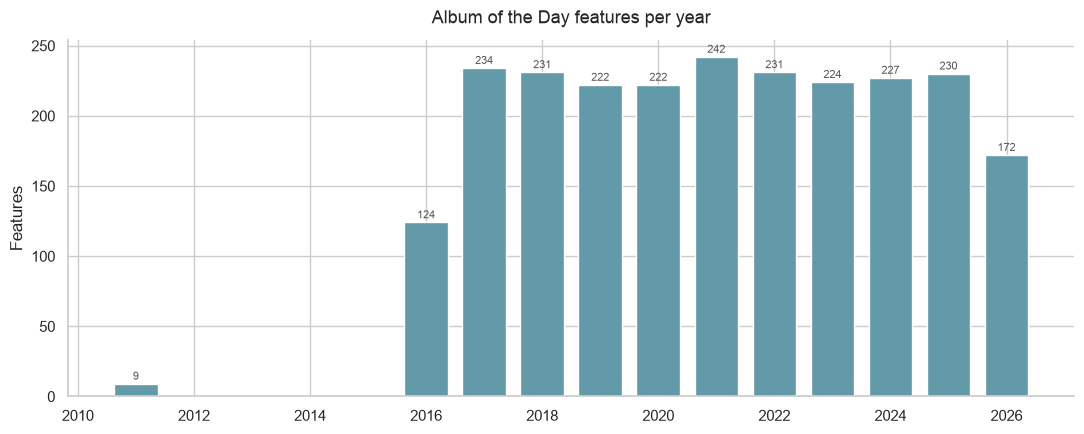

In [4]:
by_year = df.groupby(df["published_date"].dt.year).size()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(by_year.index, by_year.values, color=ACCENT, width=0.75)
ax.set_title("Album of the Day features per year", fontsize=13, pad=12)
ax.set_ylabel("Features")
ax.set_xlabel("")
ax.spines[["top", "right"]].set_visible(False)
for year, value in by_year.items():
    ax.text(year, value + 3, str(value), ha="center", fontsize=8, color="#555")
plt.tight_layout()
plt.show()

14:07:59 | INFO    | matplotlib.category            | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


14:07:59 | INFO    | matplotlib.category            | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


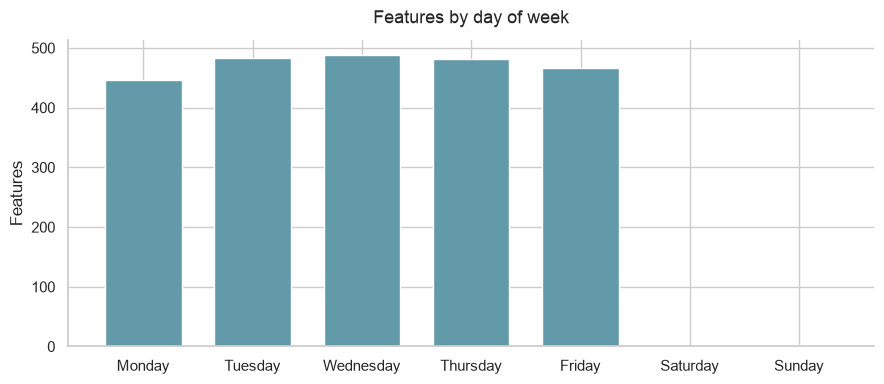

In [5]:
dow = (df["published_date"].dt.day_name()
       .value_counts()
       .reindex(["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]))

fig, ax = plt.subplots(figsize=(9, 4))
colors = [ACCENT if d not in ("Saturday", "Sunday") else "#c9d6d9" for d in dow.index]
ax.bar(dow.index, dow.values, color=colors, width=0.7)
ax.set_title("Features by day of week", fontsize=13, pad=12)
ax.set_ylabel("Features")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Genre mix

25 genre tags cover the whole archive, and the distribution is heavily skewed
— which is worth knowing before running any per-genre statistic.

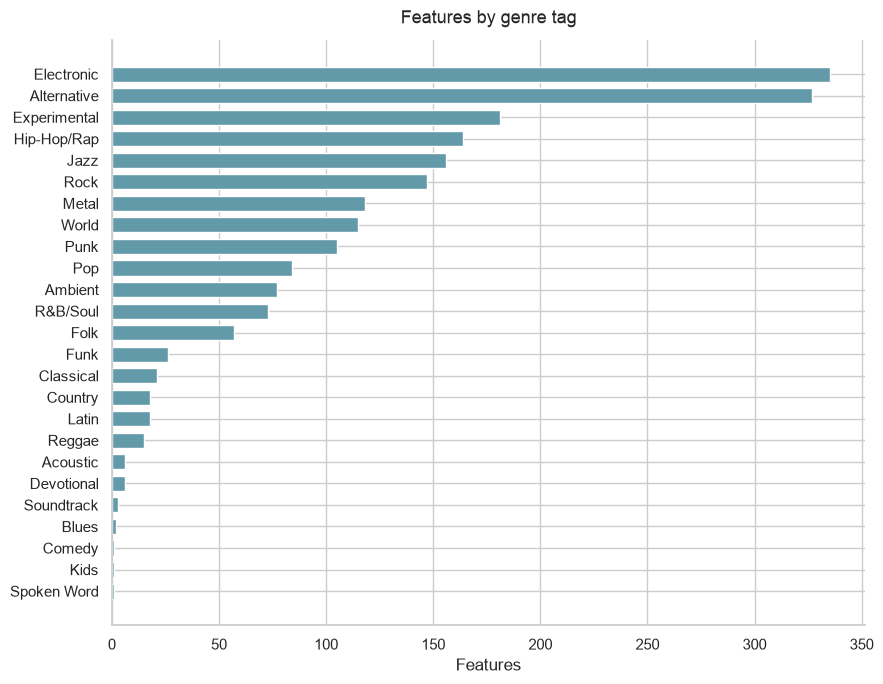

Top 5 genres account for 56.5% of all features


In [6]:
genre = df["genre_tag"].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(genre.index[::-1], genre.values[::-1], color=ACCENT, height=0.7)
ax.set_title("Features by genre tag", fontsize=13, pad=12)
ax.set_xlabel("Features")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Top 5 genres account for {genre.head(5).sum() / genre.sum():.1%} of all features")

### Genre share over time

Counts hide the interesting movement; share doesn't.

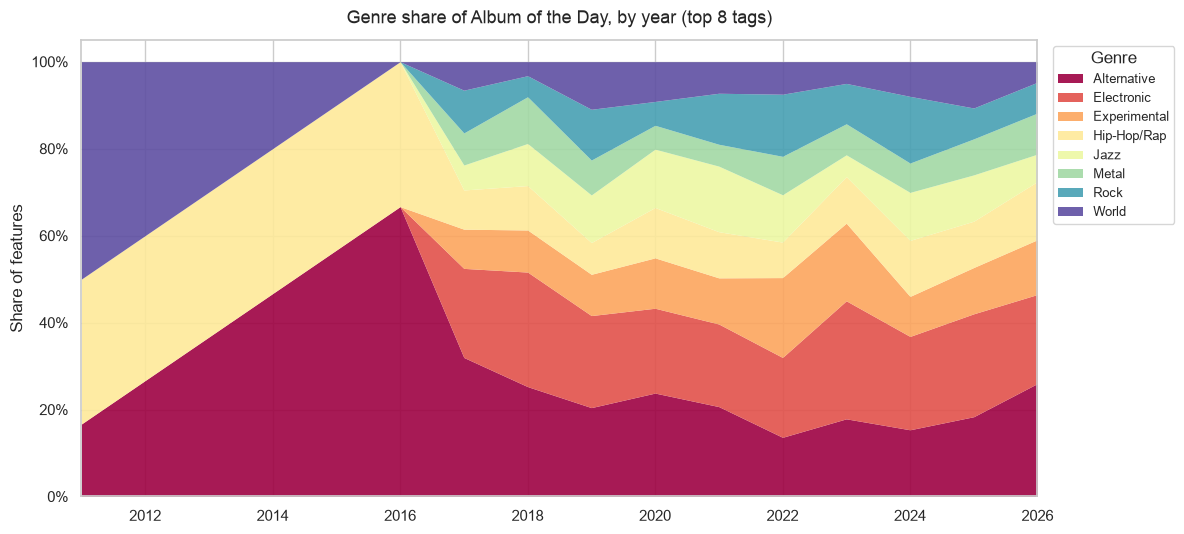

In [7]:
top_genres = genre.head(8).index
trend = (
    df[df["genre_tag"].isin(top_genres)]
    .groupby([df["published_date"].dt.year, "genre_tag"])
    .size()
    .unstack(fill_value=0)
)
share = trend.div(trend.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5.5))
share.plot(kind="area", stacked=True, ax=ax, colormap="Spectral", alpha=0.9, linewidth=0)
ax.set_title("Genre share of Album of the Day, by year (top 8 tags)", fontsize=13, pad=12)
ax.set_ylabel("Share of features")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title="Genre", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.margins(x=0)
plt.tight_layout()
plt.show()

## Independent vs. signed

The single most striking number in the dataset.

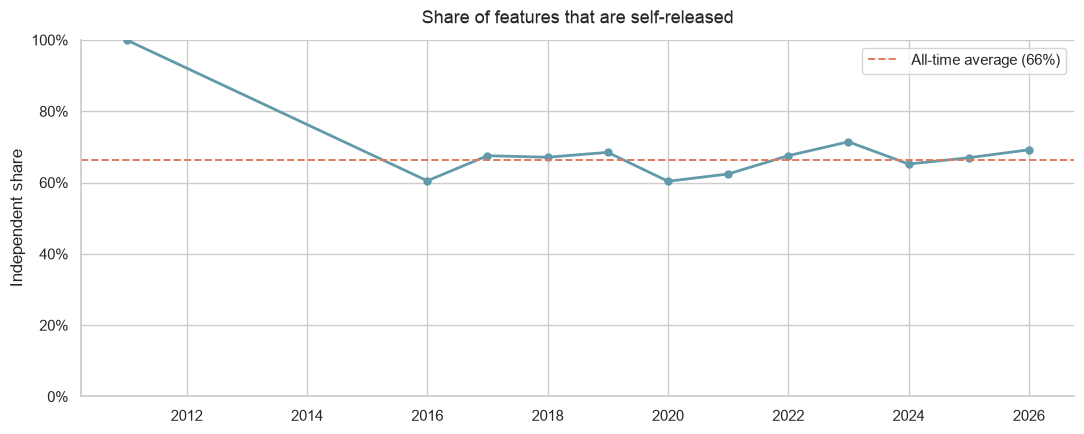

66.3% of all Album of the Day features are self-released.


In [8]:
indie_overall = df["is_independent"].mean()
indie_by_year = df.groupby(df["published_date"].dt.year)["is_independent"].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(indie_by_year.index, indie_by_year.values, marker="o",
        color=ACCENT, linewidth=2, markersize=5)
ax.axhline(indie_overall, color="#e07a5f", linestyle="--", linewidth=1.4,
           label=f"All-time average ({indie_overall:.0%})")
ax.set_title("Share of features that are self-released", fontsize=13, pad=12)
ax.set_ylabel("Independent share")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"{indie_overall:.1%} of all Album of the Day features are self-released.")

## Geography

More than half of everything featured comes from US-based labels. Whether that's a bias
or simply reflects where Bandcamp's userbase is, is the question notebook 06
takes up.

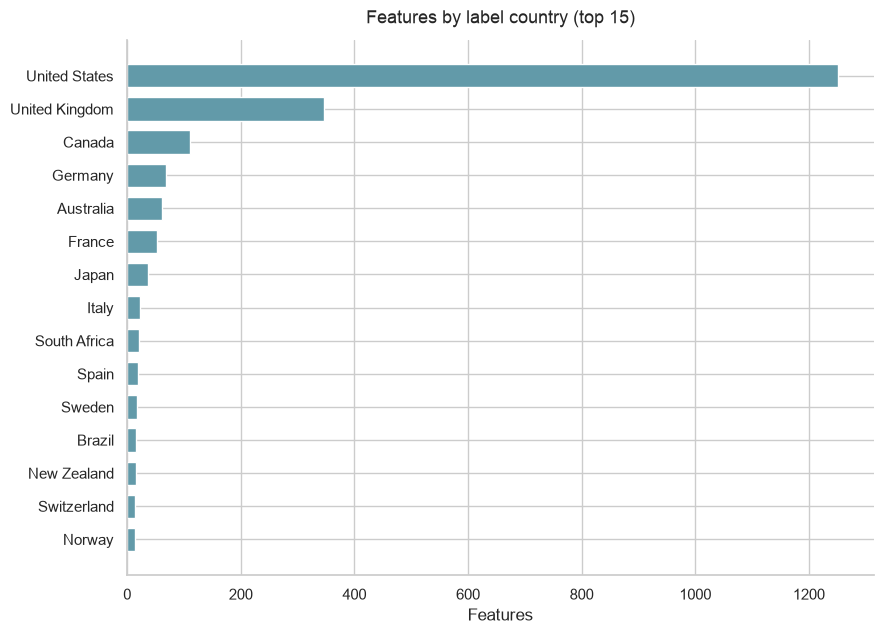

Top 3 countries account for 74.9% of all located features


In [9]:
country = df["country"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(country.index[::-1], country.values[::-1], color=ACCENT, height=0.7)
ax.set_title("Features by label country (top 15)", fontsize=13, pad=12)
ax.set_xlabel("Features")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

concentration = country.head(3).sum() / df["country"].notna().sum()
print(f"Top 3 countries account for {concentration:.1%} of all located features")

## Contributors

343 writers have contributed, but the distribution has a very long tail —
which is what makes notebook 05's author analysis restrict itself to the top
15. Comparing a writer with four reviews against one with 110 isn't a
comparison, it's noise.

349 distinct contributors
Median reviews per contributor: 2
Top 15 contributors wrote 29.0% of all features


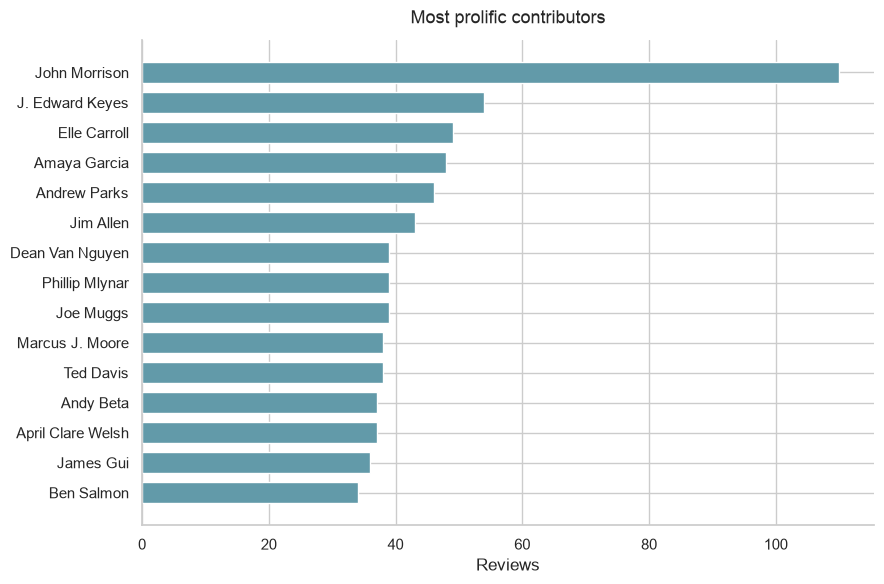

In [10]:
authors = df["author"].value_counts()

print(f"{len(authors)} distinct contributors")
print(f"Median reviews per contributor: {authors.median():.0f}")
print(f"Top 15 contributors wrote {authors.head(15).sum() / len(df):.1%} of all features")

fig, ax = plt.subplots(figsize=(9, 6))
top15 = authors.head(15)
ax.barh(top15.index[::-1], top15.values[::-1], color=ACCENT, height=0.7)
ax.set_title("Most prolific contributors", fontsize=13, pad=12)
ax.set_xlabel("Reviews")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## What this opens up

| Question | Notebook |
|---|---|
| Do individual writers have measurable genre and geography biases? | `05_editorial_bias_analysis.ipynb` |
| Are certain cities specialised in specific sounds? | `06_geographic_hubs.ipynb` |